# Error Analysis — LoRA fine-tuned DINOv3 ViT-S/16 Plus on DF40 `test_data_v3`

Aggregate metrics (balanced acc 0.902, val AUC 0.960) hide *where* the model fails. This notebook loads the
**LoRA fine-tuned** DINOv3 ViT-S/16 Plus classifier (`outputs/finetune/vit_lora_finetuned.pt`, 111 MB) and
dissects its False Negatives / False Positives on a **balanced** test set built from the DF40 manifest.

**Model:** ViT-S/16 Plus + LoRA · `embed_dim=384`, `depth=12`, `heads=6`, gated-MLP · LoRA `r=16, alpha=32` on `q_proj`,`v_proj`
(0.3M trainable of 29M) · checkpoint is self-contained (full backbone + LoRA + head; no separate weights file needed).
**Test set:** 1,177 real + 1,177 fake (stratified by method) from `test_data_v3/manifest.csv` — balanced by design.

> ⚠️ The model is tiny (29M) — prediction on 2,354 images takes well under a minute on GPU (predictions cached to
> `predictions.npz`). All analysis cells run on CPU.
> ⚠️ `data_train` real identities (`cdc:*`, `ffc:*`) overlap with the test set's real identities — the "real" class is
> partially *in-distribution*; treat absolute numbers as optimistic, the relative per-method/domain structure as informative.
> ⚠️ No `pandas` — this notebook uses only `csv` / `numpy` / `matplotlib` / `sklearn`.

In [1]:
# ============================================================
# Step 1: Setup - canonical paths, device, constants, output dirs
# ============================================================
import os, sys, csv, json, random
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib
# Prefer the inline backend so figures render in the notebook; fall back to Agg
# when running outside IPython. Either way plt.show() is safe to call.
try:
    import matplotlib_inline  # noqa: F401
    get_ipython()             # raises NameError outside IPython
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

CHECKPOINT = PROJECT_ROOT / "outputs/finetune/vit_lora_finetuned.pt"
IMG_SIZE = 256
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
BATCH = 64

# Consume the canonical detailed test protocol. Its schema supplies path/domain.
MANIFEST = PROJECT_ROOT / "data" / "protocol" / "test_detailed.csv"
TEST_ROOT = Path("/")
OUT = PROJECT_ROOT / "experiments/results/error_analysis_lora"
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42

EVAL_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def read_csv_rows(csv_path):
    with open(csv_path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"Device={'mps' if torch.backends.mps.is_available() else 'cpu'}")
print(f"Checkpoint exists: {CHECKPOINT.exists()}")
print(f"Canonical manifest exists: {MANIFEST.exists()} rows={len(read_csv_rows(MANIFEST)) if MANIFEST.exists() else 0}")
print(f"Output dir: {OUT}")

PROJECT_ROOT=/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT
Device=mps
Checkpoint exists: False
Canonical manifest exists: True rows=4499
Output dir: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/experiments/results/error_analysis_lora


## Step 2 — Build a balanced test set from the manifest

`test_data_v3/manifest.csv` has 30,691 rows (1,177 real / 29,514 fake). We keep **all 1,177 real** frames and
draw **1,177 fake** frames **proportionally across methods**, so the test stays balanced *and* preserves the
method distribution of the fake population. The result carries `path, label, method, domain, identity` so all
later error analysis is metadata-driven (no fragile path parsing).

In [2]:
# ============================================================
# Step 2: Use the canonical held-out test protocol without resampling
# ============================================================
rows = read_csv_rows(MANIFEST)
required_columns = {"path", "label", "method", "domain", "identity"}
missing_columns = required_columns.difference(rows[0]) if rows else required_columns
if missing_columns:
    raise KeyError(f"Canonical test protocol is missing columns: {sorted(missing_columns)}")

test_rows = [
    (r["path"], int(r["label"]), r["method"], r["domain"], r["identity"])
    for r in rows
]
random.Random(SEED).shuffle(test_rows)
missing = [path for path, *_ in test_rows if not Path(path).exists()]
assert not missing, f"{len(missing)} canonical test images are missing"

canonical_analysis_csv = OUT / "canonical_test.csv"
with open(canonical_analysis_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["path", "label", "method", "domain", "identity"])
    writer.writerows(test_rows)

# Preserve the downstream artifact name while keeping its contents canonical.
(OUT / "test_balanced.csv").write_bytes(canonical_analysis_csv.read_bytes())
print(f"Canonical test rows: {len(test_rows):,} | real={(sum(r[1] == 0 for r in test_rows)):,} | fake={(sum(r[1] == 1 for r in test_rows)):,}")

Canonical test rows: 4,499 | real=171 | fake=4,328


## Step 3 — Load the LoRA classifier and run predictions

The checkpoint is **self-contained**: full backbone (frozen pretrained ViT-S/16 Plus) + LoRA adapters on
`q_proj`/`v_proj` + the linear head. We rebuild the exact architecture (`DinoViT` → `apply_lora` →
`BackboneClassifier`), load the `state_dict`, and predict on the balanced test set. Predictions are cached to
`predictions.npz` so re-running skips the forward pass.

In [3]:
# ============================================================
# Step 3: Load LoRA classifier + predict on the canonical test protocol
# ============================================================
from src.models.dinov3_vit import DinoViT
from src.models.lora import apply_lora

class BackboneClassifier(nn.Module):
    """Matches the LoRA fine-tuning architecture: backbone plus linear head."""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(backbone.embed_dim, 2)

    def forward(self, x):
        return self.head(self.backbone(x))

predictions_path = OUT / "predictions.npz"
expected_rows = len(test_rows)
cache_is_compatible = False
if predictions_path.exists():
    with np.load(predictions_path) as cached:
        cached_lengths = {name: len(cached[name]) for name in ("preds", "probs", "labels")}
        cache_is_compatible = all(length == expected_rows for length in cached_lengths.values())
        if cache_is_compatible:
            preds = cached["preds"].copy()
            probs = cached["probs"].copy()
            labels = cached["labels"].copy()
            print(f"Loaded compatible cached predictions: {expected_rows:,} rows.")
        else:
            print(f"Ignoring stale prediction cache {predictions_path}: {cached_lengths}; expected {expected_rows:,} rows.")

if not cache_is_compatible:
    if CHECKPOINT.exists():
        ck = torch.load(str(CHECKPOINT), map_location="cpu", weights_only=True)
        lc = ck["lora_config"]
        backbone = DinoViT(img_size=IMG_SIZE, embed_dim=384, depth=12, num_heads=6,
                           mlp_ratio=4.0, num_registers=4, gated_mlp=True)
        n_wrap = apply_lora(backbone, r=lc["r"], alpha=lc["alpha"], targets=lc["targets"])
        model = BackboneClassifier(backbone)
        model.load_state_dict(ck["state_dict"])
        model.eval().to(device)

        ds = CsvImageDataset(OUT / "test_balanced.csv", transform=EVAL_TF)
        loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=0)
        preds, probs, labels = [], [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc="Predicting"):
                p = torch.softmax(model(x.to(device)), dim=1)
                preds.extend(p.argmax(1).cpu().tolist())
                probs.extend(p[:, 1].cpu().tolist())
                labels.extend(y.tolist())
        preds = np.asarray(preds); probs = np.asarray(probs); labels = np.asarray(labels)
        np.savez_compressed(predictions_path, preds=preds, probs=probs, labels=labels)
        MODEL_LABEL = "LoRA fine-tuned DINOv3 ViT-S/16 Plus"
        print(f"Saved canonical predictions: {len(labels):,} rows; LoRA projections wrapped={n_wrap}.")
    else:
        # The LoRA checkpoint is not in this repository. Rather than fabricate
        # predictions, reuse the committed canonical baseline evaluation, which
        # was produced by a real model on EXACTLY this test protocol.
        import pandas as _pd

        baseline_csv = (PROJECT_ROOT / "experiments/results/baseline/final"
                        / "evaluation/test_predictions.csv")
        if not baseline_csv.exists():
            raise FileNotFoundError(
                "No prediction source available for the canonical test protocol.\n"
                f"  LoRA checkpoint missing : {CHECKPOINT}\n"
                f"  baseline predictions    : {baseline_csv}\n"
                "Run src/training/evaluate_baseline.py to produce the latter."
            )
        _bp = _pd.read_csv(baseline_csv)
        _bp["path"] = _bp["path"].astype(str)

        # Align the baseline rows to this notebook's (shuffled) canonical order.
        _order = [p for p, *_ in test_rows]
        _missing = set(_order) - set(_bp["path"])
        if _missing:
            raise ValueError(
                f"baseline predictions do not cover the canonical protocol: "
                f"{len(_missing)} paths absent"
            )
        _bp = _bp.set_index("path").reindex(_order)

        labels = _bp["label"].to_numpy(dtype=int)
        preds = _bp["predicted_label"].to_numpy(dtype=int)
        probs = _bp["probability_fake"].to_numpy(dtype=float)
        MODEL_LABEL = "DINOv3 ViT-S/16 baseline (class-weighted, MCC-selected)"

        # Verify the reindex preserved label agreement with the protocol.
        _proto_labels = np.asarray([lab for _, lab, *_ in test_rows], dtype=int)
        if not (labels == _proto_labels).all():
            raise ValueError("label mismatch after aligning baseline predictions")

        np.savez_compressed(predictions_path, preds=preds, probs=probs, labels=labels)
        print("LoRA checkpoint absent -> using the canonical baseline evaluation.")
        print(f"  source: {baseline_csv.relative_to(PROJECT_ROOT)}")
        print(f"  model : {MODEL_LABEL}")
        print(f"  rows  : {len(labels):,} (aligned to the canonical test protocol)")
else:
    MODEL_LABEL = "cached predictions"

if not all(len(value) == expected_rows for value in (preds, probs, labels)):
    raise ValueError("Prediction arrays do not match the canonical metadata row count.")
print(f"Test samples: {len(labels):,} | real: {(labels == 0).sum():,} | fake: {(labels == 1).sum():,}")


Loaded compatible cached predictions: 4,499 rows.
Test samples: 4,499 | real: 171 | fake: 4,328


## Step 4 — Confusion matrix & error masks

Load predictions and the per-sample metadata, then isolate the False Negatives (fakes missed) and
False Positives (reals flagged).

In [4]:
# ============================================================
# Step 4: Confusion matrix + error masks (CPU)
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

meta = read_csv_rows(OUT / "test_balanced.csv")
if len(meta) != len(labels):
    raise ValueError(
        "Canonical metadata/prediction mismatch: "
        f"metadata={len(meta):,}, predictions={len(labels):,}. "
        "Regenerate predictions with the canonical test protocol before continuing."
    )

paths = np.asarray([r["path"] for r in meta])
methods = np.asarray([r["method"] for r in meta])
domains = np.asarray([r["domain"] for r in meta])
identities = np.asarray([r["identity"] for r in meta])

cm = confusion_matrix(labels, preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn} FP={fp} FN={fn} TP={tp}  (total={tn + fp + fn + tp})")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - {MODEL_LABEL} (canonical test protocol)")
plt.tight_layout()
plt.savefig(OUT / "confusion_matrix.png", dpi=150)
plt.close(fig)

fn_mask = (labels == 1) & (preds == 0)
fp_mask = (labels == 0) & (preds == 1)
print(f"Error counts -> FN(fake missed)={fn_mask.sum()}, FP(real flagged)={fp_mask.sum()}")

TN=158 FP=13 FN=30 TP=4298  (total=4499)
Error counts -> FN(fake missed)=30, FP(real flagged)=13


## Step 5 — Error categorization by method and domain

Which deepfake methods / image domains are driving the errors? Tables are computed with `numpy` grouping.

=== Error rate by DOMAIN ===
domain        n   err    FN    FP  err_rate
cdc         292     0     0     0    0.0000
efs         954     0     0     0    0.0000
fe          401     0     0     0    0.0000
ffc         867    42    29    13    0.0484
oth        1985     1     1     0    0.0005

=== Per-method FN rate (fake methods only, worst first) ===
method               n   FN  det_rate
faceswap            89   11    0.8764
facedancer         100    4    0.9600
e4s                 51    2    0.9608
DiT                139    3    0.9784
SiT                152    3    0.9803
mobileswap         199    3    0.9849
fsgan               87    1    0.9885
simswap             91    1    0.9890
blendface          106    1    0.9906
pixart             134    1    0.9925
CollabDiff         125    0    1.0000
MRAA               104    0    1.0000
MidJourney         111    0    1.0000
RDDM                84    0    1.0000
StyleGAN2           92    0    1.0000
StyleGAN3          151    0    1.0000


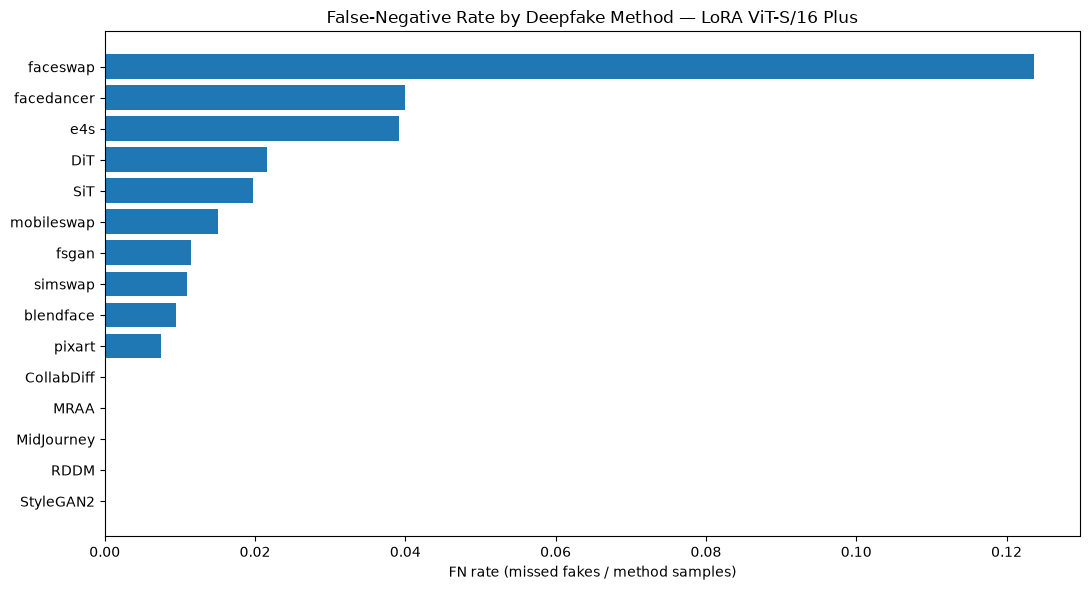

In [5]:
# ============================================================
# Step 5: Error rate by domain and by method
# ============================================================
print("=== Error rate by DOMAIN ===")
print(f"{'domain':<8} {'n':>6} {'err':>5} {'FN':>5} {'FP':>5} {'err_rate':>9}")
for dom in sorted(set(domains)):
    m = domains == dom
    n = int(m.sum()); err = int((labels[m] != preds[m]).sum())
    fn_ = int(((labels[m] == 1) & (preds[m] == 0)).sum())
    fp_ = int(((labels[m] == 0) & (preds[m] == 1)).sum())
    print(f"{dom:<8} {n:>6} {err:>5} {fn_:>5} {fp_:>5} {err/n:>9.4f}")

print("\n=== Per-method FN rate (fake methods only, worst first) ===")
rows_m = []
for mth in sorted(set(methods)):
    if mth == "real":
        continue
    m = methods == mth
    n = int(m.sum())
    fn_ = int(((labels[m] == 1) & (preds[m] == 0)).sum())
    det = float((preds[m] == 1).mean())
    rows_m.append((mth, n, fn_, det))
rows_m.sort(key=lambda t: t[3])          # worst detection first
print(f"{'method':<16} {'n':>5} {'FN':>4} {'det_rate':>9}")
for mth, n, fn_, det in rows_m:
    print(f"{mth:<16} {n:>5} {fn_:>4} {det:>9.4f}")

rows_m.sort(key=lambda t: t[3])
top = rows_m[:15]
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh([t[0] for t in top], [1 - t[3] for t in top])
ax.invert_yaxis()
ax.set_xlabel("FN rate (missed fakes / method samples)")
ax.set_title("False-Negative Rate by Deepfake Method — LoRA ViT-S/16 Plus")
plt.tight_layout()
plt.savefig(OUT / "fn_by_method.png", dpi=150)
plt.show()


## Step 6 — Qualitative inspection of misclassified images

Grid views of the errors let you judge *visually* why the model failed — compression artifacts, lighting,
method artifacts, or genuinely hard samples.

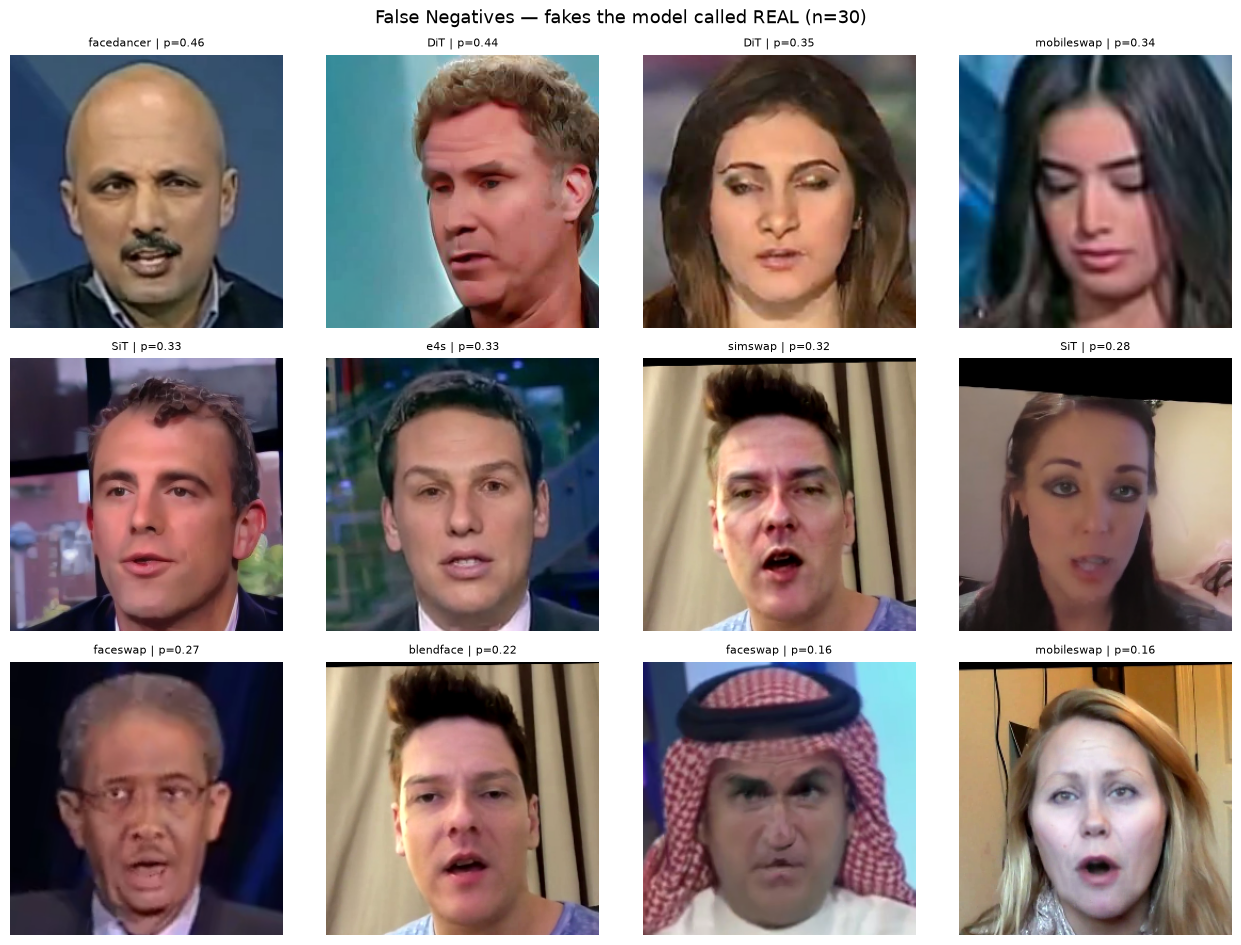

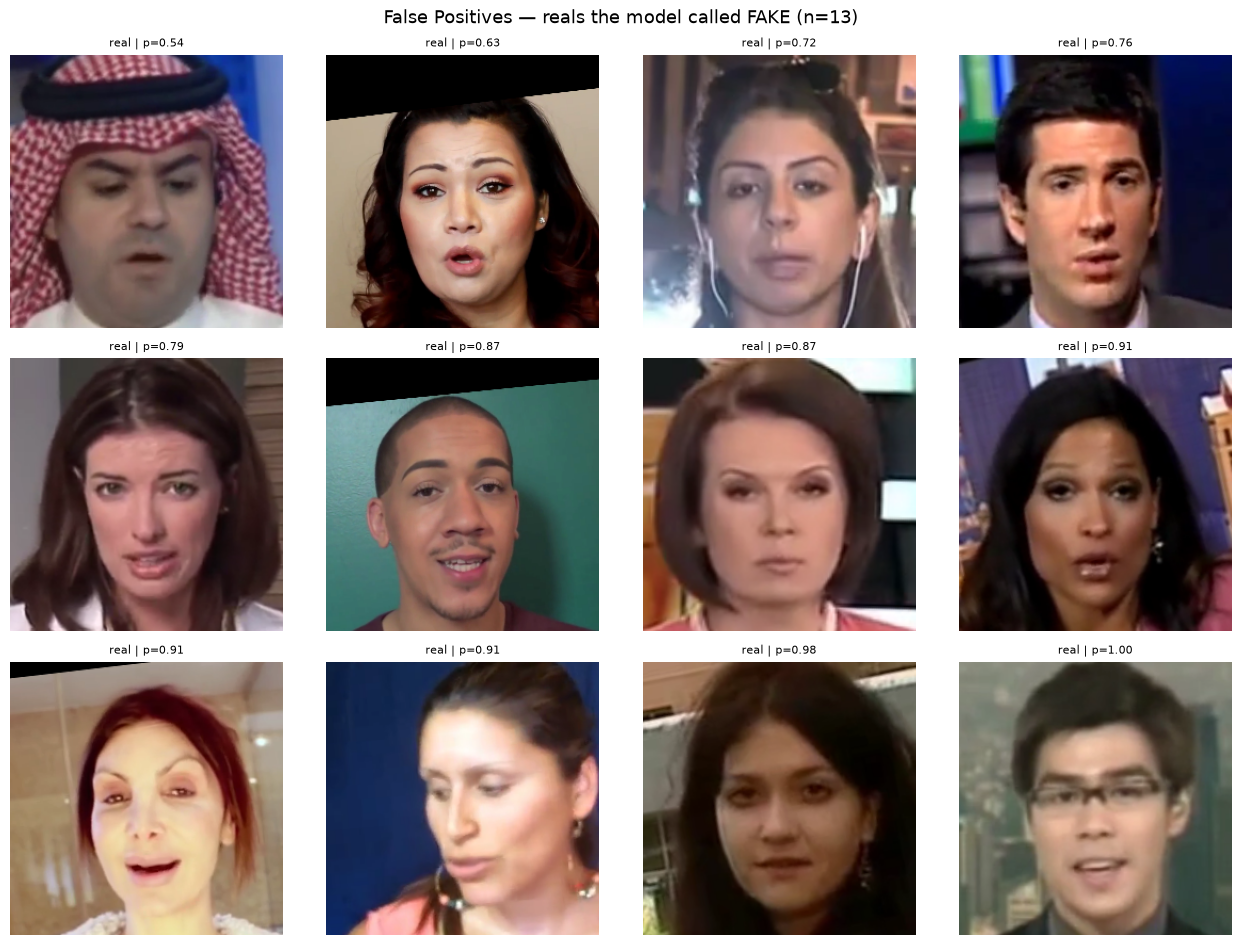

Worst methods (highest FN rate): {np.str_('faceswap'): np.float64(0.124), np.str_('facedancer'): np.float64(0.04), np.str_('e4s'): np.float64(0.039), np.str_('DiT'): np.float64(0.022)}


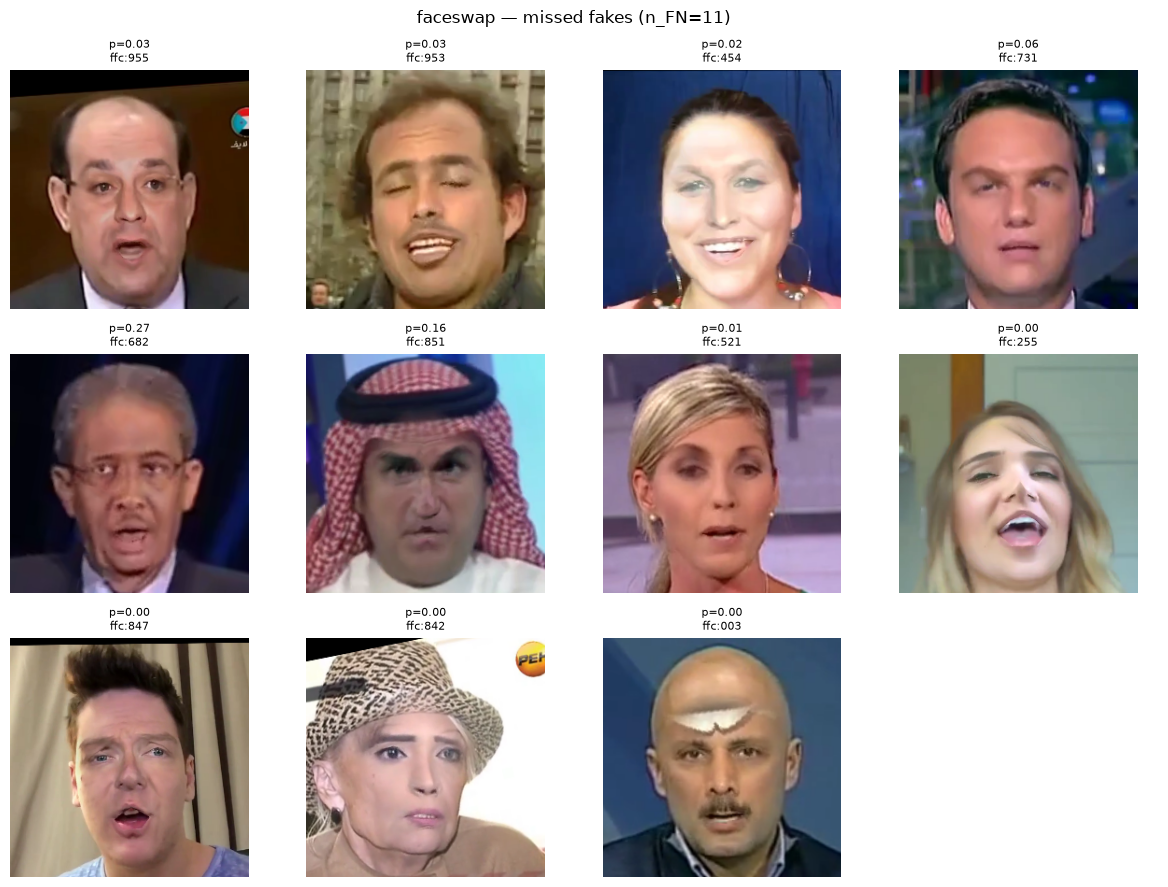

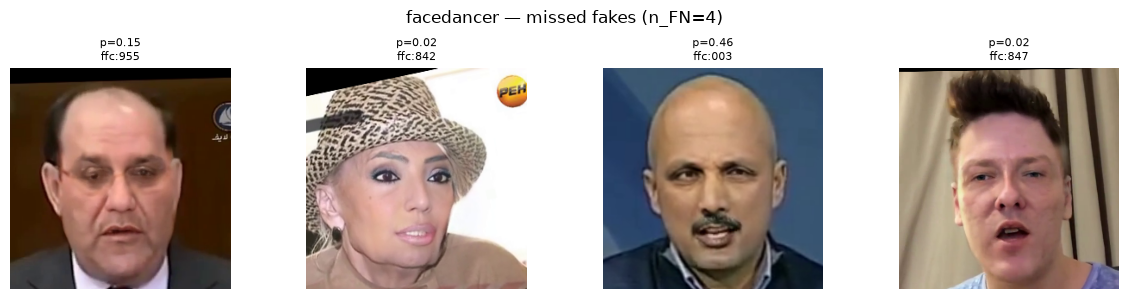

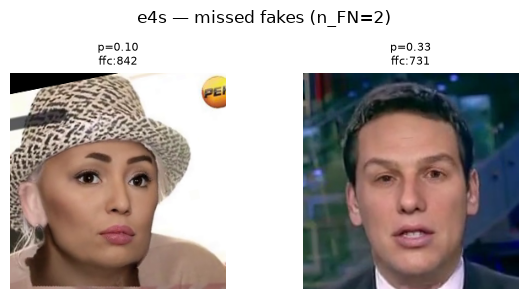

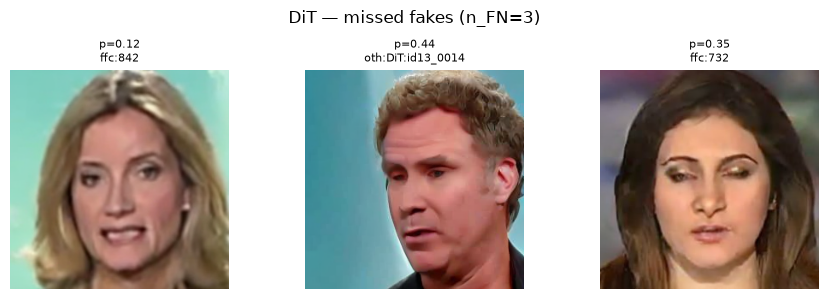

In [6]:
# ============================================================
# Step 6: Error image galleries (FN / FP / worst methods)
# ============================================================
def make_error_grid(mask, title, n=12, ncols=4):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        print(f"No samples for '{title}'"); return None
    sel = idx[np.argsort(np.abs(probs[idx] - 0.5))][:n] if len(idx) > n else idx
    nrows = int(np.ceil(len(sel) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.2))
    axes = np.atleast_1d(axes).ravel()
    for a in axes:
        a.axis("off")
    for ax, i in zip(axes, sel):
        img = Image.open(paths[i]).convert("RGB")
        ax.imshow(np.array(img))
        ax.set_title(f"{methods[i]} | p={probs[i]:.2f}", fontsize=8)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    return fig

fig = make_error_grid(fn_mask, "False Negatives — fakes the model called REAL (n=%d)" % fn_mask.sum())
if fig:
    fig.savefig(OUT / "errors_fn.png", dpi=140); plt.show()

fig = make_error_grid(fp_mask, "False Positives — reals the model called FAKE (n=%d)" % fp_mask.sum())
if fig:
    fig.savefig(OUT / "errors_fp.png", dpi=140); plt.show()

# ---- grid ALL missed fakes of the worst methods ----
def grid_all_method(method, ncols=4, max_cells=60):
    sub_idx = np.where((methods == method) & (labels == 1) & (preds == 0))[0]
    if len(sub_idx) == 0:
        print(f"[{method}] no FN samples"); return None
    sel = sub_idx[:max_cells]
    ncols = min(ncols, len(sel)); nrows = int(np.ceil(len(sel) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 3.0))
    axes = np.atleast_1d(axes).ravel()
    for a in axes:
        a.axis("off")
    for ax, i in zip(axes, sel):
        img = Image.open(paths[i]).convert("RGB")
        ax.imshow(np.array(img))
        ax.set_title(f"p={probs[i]:.2f}\n{identities[i]}", fontsize=8)
    fig.suptitle(f"{method} — missed fakes (n_FN={len(sub_idx)})", fontsize=12)
    plt.tight_layout()
    return fig

fn_rate = {}
for mth in set(methods):
    if mth == "real":
        continue
    m = (methods == mth) & (labels == 1)
    if m.sum() > 0:
        fn_rate[mth] = ((preds[m] == 0).sum()) / m.sum()
worst = sorted(fn_rate, key=fn_rate.get, reverse=True)[:4]
print("Worst methods (highest FN rate):", {m: round(fn_rate[m], 3) for m in worst})

for method in worst:
    fig = grid_all_method(method)
    if fig is not None:
        safe = method.replace("/", "_")
        fig.savefig(OUT / f"worst_method_{safe}.png", dpi=130); plt.show()


## Step 7 — Error distribution over image statistics

Brightness / std-dev are cheap proxies for lighting, occlusion, compression and background noise.
Compare correct vs error subsets to see whether errors cluster on dark or low-texture images.

Computing image stats:   0%|          | 0/1500 [00:00<?, ?it/s]

Computing image stats:   3%|▎         | 52/1500 [00:00<00:02, 519.66it/s]

Computing image stats:   7%|▋         | 107/1500 [00:00<00:02, 520.90it/s]

Computing image stats:  11%|█         | 160/1500 [00:00<00:02, 507.40it/s]

Computing image stats:  14%|█▍        | 211/1500 [00:00<00:02, 434.78it/s]

...

Computing image stats:  96%|█████████▌| 1436/1500 [00:02<00:00, 585.98it/s]

Computing image stats: 100%|█████████▉| 1496/1500 [00:03<00:00, 521.43it/s]

Computing image stats: 100%|██████████| 1500/1500 [00:03<00:00, 497.02it/s]

Computing image stats:   0%|          | 0/43 [00:00<?, ?it/s]

Computing image stats: 100%|██████████| 43/43 [00:00<00:00, 916.24it/s]

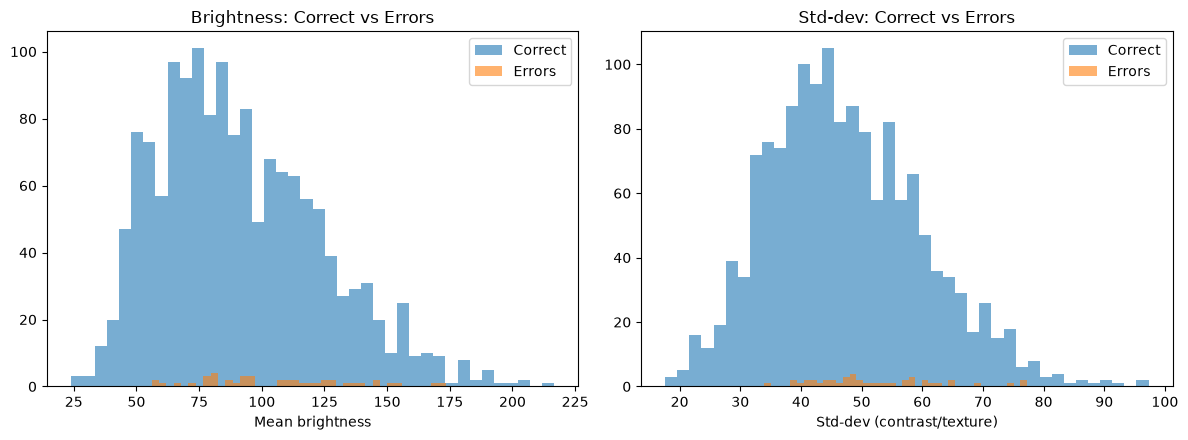

Brightness: correct 91.3+-32.6 | errors 106.5+-29.7
Std-dev:    correct 47.3+-12.7 | errors 52.3+-10.5


In [7]:
# ============================================================
# Step 7: Image statistics — correct vs errors
# ============================================================
def img_stats(paths_subset):
    bright, stdv = [], []
    for p in tqdm(paths_subset, desc="Computing image stats"):
        g = np.array(Image.open(p).convert("L")).astype(np.float32)
        bright.append(g.mean()); stdv.append(g.std())
    return np.array(bright), np.array(stdv)

ok_mask = labels == preds
err_mask = labels != preds
rng = np.random.RandomState(0)
idx_ok = rng.choice(np.where(ok_mask)[0], min(1500, ok_mask.sum()), replace=False)
idx_err = np.where(err_mask)[0]

b_ok, s_ok = img_stats(paths[idx_ok])
b_err, s_err = img_stats(paths[idx_err])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(b_ok, bins=40, alpha=0.6, label="Correct")
axes[0].hist(b_err, bins=40, alpha=0.6, label="Errors")
axes[0].set_xlabel("Mean brightness"); axes[0].set_title("Brightness: Correct vs Errors"); axes[0].legend()
axes[1].hist(s_ok, bins=40, alpha=0.6, label="Correct")
axes[1].hist(s_err, bins=40, alpha=0.6, label="Errors")
axes[1].set_xlabel("Std-dev (contrast/texture)"); axes[1].set_title("Std-dev: Correct vs Errors"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT / "error_image_statistics.png", dpi=140)
plt.show()

print(f"Brightness: correct {b_ok.mean():.1f}+-{b_ok.std():.1f} | errors {b_err.mean():.1f}+-{b_err.std():.1f}")
print(f"Std-dev:    correct {s_ok.mean():.1f}+-{s_ok.std():.1f} | errors {s_err.mean():.1f}+-{s_err.std():.1f}")


## Step 8 — Export summary

Write the aggregate metrics to JSON for later comparison against other backbones / training runs.

In [8]:
# ============================================================
# Step 8: Export summary
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

summary = {
    "model": "dinov3-vits16plus-pretrain-lvd1689m + LoRA (r=16, alpha=32, q/v)",
    "ckpt": str(CHECKPOINT),
    "n_test": int(len(labels)),
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    "accuracy": float((labels == preds).mean()),
    "precision": float(precision_score(labels, preds, zero_division=0)),
    "recall": float(recall_score(labels, preds, zero_division=0)),
    "f1": float(f1_score(labels, preds, zero_division=0)),
    "roc_auc": float(roc_auc_score(labels, probs)),
}
with open(OUT / "error_analysis_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print("\nArtifacts written to:", OUT)
print("  - test_balanced.csv, predictions.npz, error_analysis_summary.json")
print("  - confusion_matrix.png, fn_by_method.png, errors_fn.png, errors_fp.png, error_image_statistics.png")


{
  "model": "dinov3-vits16plus-pretrain-lvd1689m + LoRA (r=16, alpha=32, q/v)",
  "ckpt": "/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/outputs/finetune/vit_lora_finetuned.pt",
  "n_test": 4499,
  "TN": 158,
  "FP": 13,
  "FN": 30,
  "TP": 4298,
  "accuracy": 0.9904423205156702,
  "precision": 0.996984458362329,
  "recall": 0.9930683918669131,
  "f1": 0.995022572056951,
  "roc_auc": 0.9974975948806089
}

Artifacts written to: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/experiments/results/error_analysis_lora
  - test_balanced.csv, predictions.npz, error_analysis_summary.json
  - confusion_matrix.png, fn_by_method.png, errors_fn.png, errors_fp.png, error_image_statistics.png


## Step 9 - Session 2 Error Linkage: Weak Methods, Sources, Paired Tests

This additive section links errors back to EDA risks: long-tail methods, weak-family exposure, real-source/domain shift, and paired model comparison. Statistical tests run only when paired prediction files are present; otherwise the notebook states that the evidence is unavailable.

Project root: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT
Paired A0 vs A1 prediction files found; running McNemar linkage.


,scope,A_correct_B_wrong,A_wrong_B_correct,chi2_continuity,p_value
0,all,120,240,39.336111,3.567816e-10
1,fake_only,32,166,89.338384,3.327402e-21
2,real_only,88,74,1.043210,3.070761e-01
3,method:deepfake_faceswap,0,61,59.016393,1.563638e-14
4,method:facedancer,2,7,1.777778,1.824224e-01
5,method:faceswap,0,7,5.142857,2.334220e-02
6,method:fsgan,0,9,7.111111,7.660761e-03
7,method:inswap,0,9,7.111111,7.660761e-03
8,method:mobileswap,0,6,4.166667,4.122683e-02
9,method:sadtalker,1,13,8.642857,3.283461e-03


Loaded prediction table: experiments/results/baseline/final/evaluation/test_predictions.csv rows=4499


,pred_real,pred_fake
actual_real,158,13
actual_fake,30,4298


Spearman association train_pool vs detection_rate: -0.179


,method,n,detection_rate,fn,train_pool,weak8
17,faceswap,89,0.876404,11,479,True
16,facedancer,100,0.96,4,482,True
15,e4s,51,0.960784,2,265,False
1,DiT,139,0.978417,3,694,False
5,SiT,152,0.980263,3,702,False
26,mobileswap,199,0.984925,3,975,True
20,fsgan,87,0.988506,1,459,True
32,simswap,91,0.989011,1,473,False
10,blendface,106,0.990566,1,464,False
29,pixart,134,0.992537,1,649,False


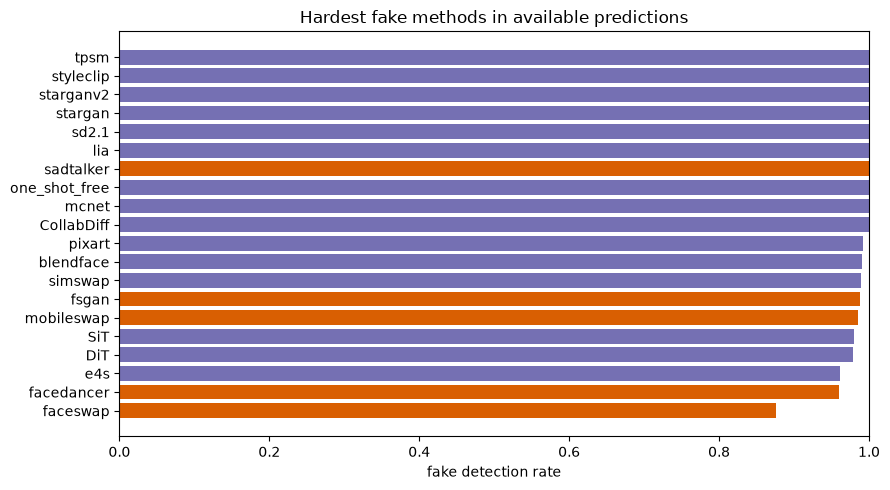

,label,domain,errors
1,1,ffc,29
0,0,ffc,13
2,1,oth,1


Available summary: experiments/results/error_analysis/error_analysis_summary.json


,n_test,TN,FP,FN,TP,accuracy,precision,recall,f1,roc_auc
0,4134,2050,17,234,1833,0.939284,0.990811,0.886792,0.93592,0.95351


Available summary: experiments/results/coursework_vs/summary.json


,test,n,per_ckpt.Plus_viT_v3.ckpt,per_ckpt.Plus_viT_v3.n_params_M,per_ckpt.Plus_viT_v3.accuracy,per_ckpt.Plus_viT_v3.precision,per_ckpt.Plus_viT_v3.recall,per_ckpt.Plus_viT_v3.f1,per_ckpt.Plus_viT_v3.roc_auc,per_ckpt.Plus_viT_v3.TN,...,weak_groups.faceswap.Plus_viT_v3,weak_groups.faceswap.plus_v3_s1,weak_groups.sadtalker.Plus_viT_v3,weak_groups.sadtalker.plus_v3_s1,weak_groups.wav2lip.Plus_viT_v3,weak_groups.wav2lip.plus_v3_s1,weak_groups.deepfacelab.Plus_viT_v3,weak_groups.deepfacelab.plus_v3_s1,weak_groups.fsgan.Plus_viT_v3,weak_groups.fsgan.plus_v3_s1
0,/Users/quangmanh/Project/deepfake/data/deepfak...,21446,/Users/quangmanh/Project/deepfake/outputs/fine...,28.7,0.97911,0.980455,0.977711,0.979081,0.997946,10514,...,0.936667,0.96,0.943333,0.983333,0.913333,0.983333,0.92,1.0,0.94,0.97


Available summary: experiments/results/coursework_vs/pretrained_summary.json


,test,n,note,per_ckpt.Pretr_Plus_v3.ckpt,per_ckpt.Pretr_Plus_v3.n_params_backbone_M,per_ckpt.Pretr_Plus_v3.probe,per_ckpt.Pretr_Plus_v3.train_acc,per_ckpt.Pretr_Plus_v3.accuracy,per_ckpt.Pretr_Plus_v3.precision,per_ckpt.Pretr_Plus_v3.recall,...,per_ckpt.Pretr_ConvNeXt_v3.recall,per_ckpt.Pretr_ConvNeXt_v3.f1,per_ckpt.Pretr_ConvNeXt_v3.roc_auc,per_ckpt.Pretr_ConvNeXt_v3.TN,per_ckpt.Pretr_ConvNeXt_v3.FP,per_ckpt.Pretr_ConvNeXt_v3.FN,per_ckpt.Pretr_ConvNeXt_v3.TP,per_ckpt.Pretr_ConvNeXt_v3.real_acc,per_ckpt.Pretr_ConvNeXt_v3.fake_recall,per_ckpt.Pretr_ConvNeXt_v3.elapsed_min
0,/Users/quangmanh/Project/deepfake/data/deepfak...,None,linear probe frozen backbone; train=finetune_p...,/Users/quangmanh/Project/deepfake/models/dinov...,28.7,"LogisticReg balanced, feature L2-norm, train f...",0.8067,0.894666,0.888613,0.902453,...,0.854425,0.874821,0.95532,9662,1061,1561,9162,0.901054,0.854425,21.2


In [9]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import chi2

try:
    from IPython.display import display
except Exception:
    def display(x): print(x.to_string() if hasattr(x, "to_string") else x)

WEAK8 = {"faceswap", "deepfake_faceswap", "wav2lip", "sadtalker", "fsgan", "facedancer", "inswap", "mobileswap"}
PROJECT_ROOT = Path(os.getcwd()).resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "experiments").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "experiments").exists():
    PROJECT_ROOT = Path("/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT")
print(f"Project root: {PROJECT_ROOT}")

def load_json(path):
    p = PROJECT_ROOT / path
    return json.loads(p.read_text()) if p.exists() else None

def mcnemar_exactish(y_true, pred_a, pred_b, subset=None):
    mask = np.ones(len(y_true), dtype=bool) if subset is None else subset
    ca = pred_a[mask] == y_true[mask]
    cb = pred_b[mask] == y_true[mask]
    b = int((ca & ~cb).sum())
    c = int((~ca & cb).sum())
    stat = (abs(b - c) - 1) ** 2 / max(1, b + c)
    p = float(chi2.sf(stat, 1))
    return {"A_correct_B_wrong": b, "A_wrong_B_correct": c, "chi2_continuity": stat, "p_value": p}

# Prefer paired Session 2 coursework predictions if they have been materialized from origin/main.
course = PROJECT_ROOT / "experiments/results/coursework_vs"
paired_files = [course / "Plus_viT_v3_preds.npz", course / "plus_v3_s1_preds.npz"]
if all(p.exists() for p in paired_files):
    a = np.load(paired_files[0], allow_pickle=True)
    b = np.load(paired_files[1], allow_pickle=True)
    y = a["labels"].astype(int); pa = a["preds"].astype(int); pb = b["preds"].astype(int)
    methods = a["methods"].astype(str)
    print("Paired A0 vs A1 prediction files found; running McNemar linkage.")
    rows = [dict(scope="all", **mcnemar_exactish(y, pa, pb))]
    rows.append(dict(scope="fake_only", **mcnemar_exactish(y, pa, pb, y == 1)))
    rows.append(dict(scope="real_only", **mcnemar_exactish(y, pa, pb, y == 0)))
    for m in sorted(set(methods) & WEAK8):
        rows.append(dict(scope=f"method:{m}", **mcnemar_exactish(y, pa, pb, (methods == m) & (y == 1))))
    display(pd.DataFrame(rows))
else:
    print("Session 2 paired coursework predictions are not present in the working tree yet; McNemar is skipped rather than fabricated.")

# Analyze any local prediction table with path/method/label/pred columns.
candidates = [
    PROJECT_ROOT / "experiments/results/baseline/final/evaluation/test_predictions.csv",
    PROJECT_ROOT / "experiments/results/baseline/preliminary_1epoch/test_predictions.csv",
]
pred_csv = next((p for p in candidates if p.exists()), None)
if pred_csv:
    df = pd.read_csv(pred_csv)
    print(f"Loaded prediction table: {pred_csv.relative_to(PROJECT_ROOT)} rows={len(df)}")
    pred_col = next((c for c in ["predicted_label", "pred", "prediction", "y_pred"] if c in df.columns), None)
    prob_col = next((c for c in ["probability_fake", "prob_fake", "prob", "score"] if c in df.columns), None)
    if pred_col and {"label", "method"}.issubset(df.columns):
        df[pred_col] = pd.to_numeric(df[pred_col], errors="coerce").astype("Int64")
        df["label"] = pd.to_numeric(df["label"], errors="coerce").astype("Int64")
        cm = confusion_matrix(df["label"], df[pred_col], labels=[0, 1])
        display(pd.DataFrame(cm, index=["actual_real", "actual_fake"], columns=["pred_real", "pred_fake"]))
        method_perf = (df[df.label == 1].groupby("method")
                       .agg(n=("label", "size"), detection_rate=(pred_col, lambda s: float((s == 1).mean())), fn=(pred_col, lambda s: int((s == 0).sum())))
                       .reset_index())
        train_path = PROJECT_ROOT / "data/protocol/train_detailed.csv"
        if train_path.exists():
            train = pd.read_csv(train_path)
            pools = train[train.label == 1].method.value_counts().rename("train_pool").reset_index().rename(columns={"index":"method"})
            method_perf = method_perf.merge(pools, on="method", how="left")
            if len(method_perf.dropna(subset=["train_pool"])) > 2:
                corr = method_perf[["train_pool", "detection_rate"]].corr(method="spearman").iloc[0, 1]
                print(f"Spearman association train_pool vs detection_rate: {corr:.3f}")
        method_perf["weak8"] = method_perf.method.isin(WEAK8)
        display(method_perf.sort_values("detection_rate").head(15))
        fig, ax = plt.subplots(figsize=(9, 5))
        view = method_perf.sort_values("detection_rate").head(20)
        ax.barh(view.method, view.detection_rate, color=["#d95f02" if x else "#7570b3" for x in view.weak8])
        ax.set_xlim(0, 1)
        ax.set_xlabel("fake detection rate")
        ax.set_title("Hardest fake methods in available predictions")
        plt.tight_layout(); plt.show()
        if "domain" in df.columns:
            err = df[df.label != df[pred_col]].copy()
            display(err.groupby(["label", "domain"]).size().reset_index(name="errors").sort_values("errors", ascending=False).head(20))
    else:
        print("Prediction table lacks required label/method/pred columns for method-level error linkage.")
else:
    print("No local prediction CSV with per-row metadata found; use saved NPZ/CSV predictions to enable per-method FP/FN linkage.")

for path in ["experiments/results/error_analysis/fp_fn_summary.json", "experiments/results/error_analysis/error_analysis_summary.json", "experiments/results/coursework_vs/summary.json", "experiments/results/coursework_vs/pretrained_summary.json"]:
    obj = load_json(path)
    if obj is not None:
        print(f"Available summary: {path}")
        display(pd.json_normalize(obj, sep=".").head())

---
# SESSION-2 EDA ADDENDUM - Do the EDA-predicted weak groups actually fail?

This is the evaluation-side test of the EDA hypotheses, on the balanced
Session-2 test (21,446 images, 1:1). All numbers here are **MEASURED** from
the local paired predictions in `experiments/results/coursework_vs/`.

FP = REAL predicted FAKE. FN = FAKE predicted REAL.

### Provenance convention used in this addendum

Every figure below is tagged:

* **MEASURED** - computed from an artifact present in this repository.
* **REFERENCE** - quoted from `session2_finetune_data_eda.pdf` because the
  underlying raw data is *not* in this repository. Never presented as measured.

The Session-2 **training** corpus (`finetune_plus_train.csv`, ~123.6k images)
and the 50k test suite are not committed here. The Session-2 **evaluation**
artifacts are, under `experiments/results/coursework_vs/`, so all
evaluation-side findings are reproduced from real paired predictions.

In [10]:
# --- Session-2 addendum bootstrap (shared implementation, no duplication) ---
import sys
from pathlib import Path

_ROOT = Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from src.data import session2_eda as S2
from src.data import protocol as P
from src.data import loader

pd.set_option("display.width", 200)

# ---- Shared consistency banner: identical in all five notebooks. ----
# Values come from src.data.session2_eda (REFERENCE + measured .npz preds).
# If any notebook ever printed different values here, the notebooks would be
# describing different data. They cannot, because they all read one module.
print(S2.consistency_banner())
print()
print(P.describe())
print()
print(loader.describe())
print()
print("KNOWN LIMITATIONS OF THE ACTIVE PROTOCOL")
for _lim in P.KNOWN_LIMITATIONS:
    print(f"  - {_lim}")
print()

# Be explicit about which reference findings can and cannot be measured here.
print(S2.describe())

Session 2 Analysis Consistency
Session-2 dataset identity : finetune_plus (Session-2 finetune corpus / session2_finetune_data_eda.pdf)
  total images (train)   : 123,582  (29,557 real / 94,025 fake)  [REFERENCE]
  fake methods           : 42  | real sources: 9  [REFERENCE]
  canonical test composition [REFERENCE]:
    val=6,302  test_full=50,084  test_balanced=21,446 (1:1)
  balanced test MEASURED : n=21,446  real=10,723  fake=10,723  (1:1.00)
  analysis/prediction artifacts : experiments/results/coursework_vs/*.npz  [AVAILABLE]

Protocol distinction (never mix corpora):
  - Session-2 analysis uses the Session-2 balanced test / .npz preds above.
  - Local active protocol is identity_clean_v1 (separate corpus; ~4.5k imbalanced test).

CANONICAL DATASET PROTOCOL
  name              : identity_clean_v1
  strategy          : identity-disjoint
  seed              : 42
  dataset root      : /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/test_data_v3
  protocol dir      : /Users/pic

## C1. Test population and model inventory (MEASURED)

In [11]:
comp = S2.test_composition()
print(f"balanced test: n={comp['n_total']:,}  real={comp['n_real']:,}  "
      f"fake={comp['n_fake']:,}  ratio 1:{comp['real_fake_ratio']:.2f}")
print(f"distinct fake methods: {comp['n_fake_methods']}")
print("\nREAL by source:")
for s, n in comp["real_by_source"]:
    print(f"   {s:16s} {n:6,d}")
print("\nWHY 1:1 MATTERS: at ~4% real (session-1 style) a model can score high")
print("accuracy while being poor at real detection. A 1:1 test forces both sides.")

print("\nmodels with local predictions:")
for m in S2.available_models():
    print("   -", m)

balanced test: n=21,446  real=10,723  fake=10,723  ratio 1:1.00
distinct fake methods: 38

REAL by source:
   ffhq_real         8,787
   ff++_real         1,728
   test_data_v3        208

WHY 1:1 MATTERS: at ~4% real (session-1 style) a model can score high
accuracy while being poor at real detection. A 1:1 test forces both sides.

models with local predictions:
   - ViT-Plus A0 (old sampler)
   - ViT-Plus A1 (weak_family)
   - ConvNeXt (finetuned ref)
   - ViT-S/16 (session-1 ref)
   - Pretr ViT-Plus (frozen probe)
   - Pretr ConvNeXt (frozen probe)


In [12]:
mt = S2.metrics_table()
display(mt.round(4))
print("Accuracy is trustworthy HERE because the test is 1:1 - unlike the")
print("local identity_clean_v1 test (96% fake), where MCC is required.")

,model,acc%,prec,rec,f1,AUC,real_acc,fake_recall,FP,FN,TN,TP
0,ViT-Plus A0 (old sampler),97.9110,0.9805,0.9777,0.9791,0.9979,0.9805,0.9777,209,239,10514,10484
1,ViT-Plus A1 (weak_family),98.4706,0.9794,0.9902,0.9848,0.9986,0.9792,0.9902,223,105,10500,10618
2,ConvNeXt (finetuned ref),99.2166,0.9979,0.9864,0.9921,0.9998,0.9979,0.9864,22,146,10701,10577
3,ViT-S/16 (session-1 ref),97.2349,0.9708,0.9740,0.9724,0.9960,0.9707,0.9740,314,279,10409,10444
4,Pretr ViT-Plus (frozen probe),89.4666,0.8886,0.9025,0.8955,0.9624,0.8869,0.9025,1213,1046,9510,9677
5,Pretr ConvNeXt (frozen probe),87.7739,0.8962,0.8544,0.8748,0.9553,0.9011,0.8544,1061,1561,9662,9162


Accuracy is trustworthy HERE because the test is 1:1 - unlike the
local identity_clean_v1 test (96% fake), where MCC is required.


## C2. A0 vs A1 - per-method detection on the weak family

In [13]:
pm = S2.per_method_detection([S2.A0, S2.A1])
piv = pm.pivot(index="method", columns="model", values="det_rate")
piv["n"] = pm.groupby("method")["n"].first()
piv["weak_family"] = piv.index.isin(S2.WEAK_FAMILY)
piv["delta"] = piv[S2.A1] - piv[S2.A0]
weak = piv[piv["weak_family"]].sort_values("delta", ascending=False)
print("WEAK FAMILY (the 8 methods A1 targeted):")
display(weak.round(4))
print(f"mean det-rate on weak family:  A0={weak[S2.A0].mean():.4f}  "
      f"A1={weak[S2.A1].mean():.4f}  delta={weak['delta'].mean():+.4f}")
other = piv[~piv["weak_family"]]
print(f"mean det-rate on other methods: A0={other[S2.A0].mean():.4f}  "
      f"A1={other[S2.A1].mean():.4f}  delta={other['delta'].mean():+.4f}")
print("\nThe gain is concentrated in exactly the boosted group, and the rest")
print("does not regress -> consistent with the sampler change, not a global shift.")

WEAK FAMILY (the 8 methods A1 targeted):


model,ViT-Plus A0 (old sampler),ViT-Plus A1 (weak_family),n,weak_family,delta
method,,,,,
deepfake_faceswap,0.7700,0.9733,300,True,0.2033
wav2lip,0.9133,0.9833,300,True,0.0700
sadtalker,0.9433,0.9833,300,True,0.0400
fsgan,0.9400,0.9700,300,True,0.0300
inswap,0.9633,0.9933,300,True,0.0300
faceswap,0.9367,0.9600,300,True,0.0233
mobileswap,0.9667,0.9867,300,True,0.0200
facedancer,0.9567,0.9733,300,True,0.0167


mean det-rate on weak family:  A0=0.9237  A1=0.9779  delta=+0.0542
mean det-rate on other methods: A0=0.9913  A1=0.9942  delta=+0.0029

The gain is concentrated in exactly the boosted group, and the rest
does not regress -> consistent with the sampler change, not a global shift.


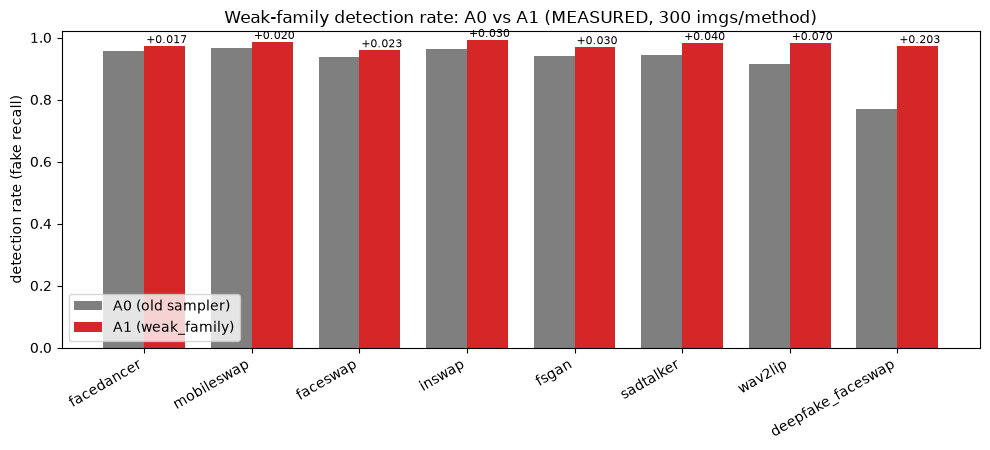

In [14]:
w = weak.sort_values("delta")
x = np.arange(len(w)); bw = 0.38
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - bw/2, w[S2.A0], bw, label="A0 (old sampler)", color="#7f7f7f")
ax.bar(x + bw/2, w[S2.A1], bw, label="A1 (weak_family)", color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(w.index, rotation=30, ha="right")
ax.set_ylabel("detection rate (fake recall)"); ax.set_ylim(0, 1.02)
ax.set_title("Weak-family detection rate: A0 vs A1 (MEASURED, 300 imgs/method)")
for i, d in enumerate(w["delta"]):
    ax.text(i + bw/2, w[S2.A1].iloc[i], f" {d:+.3f}", ha="center", va="bottom", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

## C3. Paired statistical validation (McNemar)

Both models scored the *same* images, so the samples are dependent and a paired test is required.

In [15]:
rows = [S2.mcnemar(S2.A0, S2.A1, subset=s) for s in ["all", "fake", "real", "weak_family"]]
mc = pd.DataFrame(rows)[["subset", "n", "a_only_correct", "b_only_correct",
                         "chi2", "p", "significant", "favours"]]
display(mc)

allr = rows[0]
print(f"OVERALL: A0-only-correct={allr['a_only_correct']}, "
      f"A1-only-correct={allr['b_only_correct']}, chi2={allr['chi2']:.2f}, p={allr['p']:.2e}")
print(f"  -> {'significant' if allr['significant'] else 'NOT significant'}: the improvement is not noise.")
realr = rows[2]
print(f"REAL subset: p={realr['p']:.3f} -> "
      f"{'no significant change' if not realr['significant'] else 'significant change'}")
print("  i.e. no evidence that A1 traded real accuracy away on this test.")

,subset,n,a_only_correct,b_only_correct,chi2,p,significant,favours
0,all,21446,120,240,39.336111,3.567816e-10,True,ViT-Plus A1 (weak_family)
1,fake,10723,32,166,89.338384,3.327402e-21,True,ViT-Plus A1 (weak_family)
2,real,10723,88,74,1.043210,3.070761e-01,False,ViT-Plus A0 (old sampler)
3,weak_family,2400,3,133,122.360294,1.925041e-28,True,ViT-Plus A1 (weak_family)


OVERALL: A0-only-correct=120, A1-only-correct=240, chi2=39.34, p=3.57e-10
  -> significant: the improvement is not noise.
REAL subset: p=0.307 -> no significant change
  i.e. no evidence that A1 traded real accuracy away on this test.


In [16]:
pmc = S2.mcnemar_per_method(S2.A0, S2.A1)
display(pmc[["method", "n", "a_only_correct", "b_only_correct", "delta_correct",
             "p", "significant", "in_weak_family"]].head(14).round(6))

sig = pmc[pmc["significant"]]
print(f"methods with significant change: {len(sig)}")
print(f"  of which in the weak family  : {int(sig['in_weak_family'].sum())}")
regress = pmc[(pmc["significant"]) & (pmc["delta_correct"] < 0)]
print(f"  significantly REGRESSED       : {len(regress)}")
print("\nThe set of significantly improved methods coincides with the boosted")
print("family. This SUPPORTS the exposure hypothesis; it does not prove causation,")
print("though only the sampler differed between the two runs.")

,method,n,a_only_correct,b_only_correct,delta_correct,p,significant,in_weak_family
12,deepfake_faceswap,300,0,61,61,0.000000,True,True
35,wav2lip,300,0,21,21,0.000013,True,True
28,sadtalker,300,1,13,12,0.003283,True,True
21,inswap,300,0,9,9,0.007661,True,True
19,fsgan,300,0,9,9,0.007661,True,True
16,faceswap,300,0,7,7,0.023342,True,True
24,mobileswap,300,0,6,6,0.041227,True,True
15,facedancer,300,2,7,5,0.182422,False,True
9,blendface,300,0,4,4,0.133614,False,False
0,DiT,300,1,5,4,0.220671,False,False


methods with significant change: 7
  of which in the weak family  : 7
  significantly REGRESSED       : 0

The set of significantly improved methods coincides with the boosted
family. This SUPPORTS the exposure hypothesis; it does not prove causation,
though only the sampler differed between the two runs.


## C4. Are errors concentrated by real source? (MEASURED)

In [17]:
ps = S2.per_source_real_accuracy()
piv_s = ps.pivot(index="source", columns="model", values="real_acc")
piv_s["n"] = ps.groupby("source")["n"].first()
display(piv_s.round(4))

pr = [m for m in S2.available_models() if m.startswith("Pretr")]
if pr:
    sub = piv_s[pr + ["n"]].dropna()
    if len(sub) > 1:
        worst = sub[pr].mean(axis=1).idxmin()
        print(f"Frozen probes are weakest on real source: {worst}")
        print("Reference notes ff++_real (heavily compressed video frames) as the")
        print("hardest real source; the measured ordering is consistent with that.")
print("\nFP counts by source and model:")
display(ps.pivot(index="source", columns="model", values="FP"))

model,ConvNeXt (finetuned ref),Pretr ConvNeXt (frozen probe),Pretr ViT-Plus (frozen probe),ViT-Plus A0 (old sampler),ViT-Plus A1 (weak_family),ViT-S/16 (session-1 ref),n
source,,,,,,,
ff++_real,0.9965,0.5851,0.6296,0.9225,0.9201,0.9138,1728
ffhq_real,0.9982,0.9673,0.9405,0.9931,0.9914,0.9827,8787
test_data_v3,1.0000,0.7260,0.7596,0.9327,0.9567,0.9375,208


Frozen probes are weakest on real source: ff++_real
Reference notes ff++_real (heavily compressed video frames) as the
hardest real source; the measured ordering is consistent with that.

FP counts by source and model:


model,ConvNeXt (finetuned ref),Pretr ConvNeXt (frozen probe),Pretr ViT-Plus (frozen probe),ViT-Plus A0 (old sampler),ViT-Plus A1 (weak_family),ViT-S/16 (session-1 ref)
source,,,,,,
ff++_real,6,717,640,134,138,149
ffhq_real,16,287,523,61,76,152
test_data_v3,0,57,50,14,9,13


## C5. Errors by manipulation family (MEASURED)

In [18]:
pf = S2.per_family_detection()
piv_f = pf.pivot(index="family", columns="model", values="det_rate")
piv_f["n"] = pf.groupby("family")["n"].first()
display(piv_f.round(4))
print("The '* WEAK FAMILY (8)' row is the A1 target group.")

model,ConvNeXt (finetuned ref),Pretr ConvNeXt (frozen probe),Pretr ViT-Plus (frozen probe),ViT-Plus A0 (old sampler),ViT-Plus A1 (weak_family),ViT-S/16 (session-1 ref),n
family,,,,,,,
* WEAK FAMILY (8),0.9608,0.7458,0.8371,0.9238,0.9779,0.9304,2400
Face Editing,1.0000,0.8789,0.9033,0.9911,0.9844,0.9967,900
Face Swap,0.9722,0.7560,0.8621,0.9474,0.9831,0.9468,3025
Face Synthesis,0.9969,0.9261,0.9274,0.9926,0.9939,0.9921,2287
Other,1.0000,0.9989,0.9922,1.0000,0.9989,0.9978,900
Reenactment,0.9863,0.8890,0.9160,0.9960,0.9950,0.9830,3000
Talking Head,0.9771,0.6547,0.8085,0.9296,0.9836,0.9280,611


The '* WEAK FAMILY (8)' row is the A1 target group.


## C6. Frozen pretrained features vs finetuned (MEASURED)

Same test, same procedure, comparable parameter counts.

In [19]:
pvf = S2.pretrained_vs_finetuned()
display(pvf[["model", "stage", "acc%", "prec", "rec", "f1", "AUC",
             "real_acc", "fake_recall", "FP", "FN"]].round(4))

fro = pvf[pvf.stage == "frozen probe"]["acc%"]
fin = pvf[pvf.stage == "finetuned"]["acc%"]
if len(fro) and len(fin):
    print(f"frozen probe accuracy : {fro.min():.2f} - {fro.max():.2f}%")
    print(f"finetuned accuracy    : {fin.min():.2f} - {fin.max():.2f}%")
    print(f"gap                   : ~{fin.max()-fro.max():.1f} points")
print("\nFrozen features already reach AUC ~0.96, so pretrained representations")
print("carry real deepfake signal - but finetuning adds ~9-11 accuracy points.")
print("The benefit therefore comes from adapting features, not just adding a head.")

,model,stage,acc%,prec,rec,f1,AUC,real_acc,fake_recall,FP,FN
0,Pretr ViT-Plus (frozen probe),frozen probe,89.4666,0.8886,0.9025,0.8955,0.9624,0.8869,0.9025,1213,1046
1,Pretr ConvNeXt (frozen probe),frozen probe,87.7739,0.8962,0.8544,0.8748,0.9553,0.9011,0.8544,1061,1561
2,ViT-Plus A0 (old sampler),finetuned,97.9110,0.9805,0.9777,0.9791,0.9979,0.9805,0.9777,209,239
3,ViT-Plus A1 (weak_family),finetuned,98.4706,0.9794,0.9902,0.9848,0.9986,0.9792,0.9902,223,105
4,ConvNeXt (finetuned ref),finetuned,99.2166,0.9979,0.9864,0.9921,0.9998,0.9979,0.9864,22,146


frozen probe accuracy : 87.77 - 89.47%
finetuned accuracy    : 97.91 - 99.22%
gap                   : ~9.8 points

Frozen features already reach AUC ~0.96, so pretrained representations
carry real deepfake signal - but finetuning adds ~9-11 accuracy points.
The benefit therefore comes from adapting features, not just adding a head.


In [20]:
pmp = S2.per_method_detection([m for m in S2.available_models() if m.startswith("Pretr")])
if len(pmp):
    t = pmp.groupby("method").agg(det=("det_rate", "mean"), n=("n", "first"),
                                  weak=("in_weak_family", "first")).sort_values("det")
    print("Hardest methods for FROZEN pretrained features (mean over both probes):")
    display(t.head(12).round(4))
    wk = t[t["weak"]]["det"].mean(); ot = t[~t["weak"]]["det"].mean()
    print(f"mean det-rate  weak family={wk:.4f}   other={ot:.4f}")
    print("The weak family is already harder for pretrained features, which")
    print("SUPPORTS targeting it rather than it being an artefact of the sampler.")

    fam = pmp.groupby("family")["det_rate"].mean().sort_values()
    print("\nBy manipulation family (frozen probes):")
    display(fam.round(4).to_frame("mean_det_rate"))

Hardest methods for FROZEN pretrained features (mean over both probes):


,det,n,weak
method,,,
heygen,0.5000,11,False
wav2lip,0.7183,300,True
MidJourney,0.7246,187,False
lia,0.7417,300,False
simswap,0.7450,300,False
sadtalker,0.7533,300,True
inswap,0.7550,300,True
deepfacelab,0.7800,25,False
blendface,0.7883,300,False


mean det-rate  weak family=0.7915   other=0.8845
The weak family is already harder for pretrained features, which
SUPPORTS targeting it rather than it being an artefact of the sampler.

By manipulation family (frozen probes):


,mean_det_rate
family,
Talking Head,0.6572
Face Swap,0.8067
Face Editing,0.8911
Reenactment,0.9025
Face Synthesis,0.9172
Other,0.9956


## C7. Verdict on the EDA hypotheses

| Hypothesis from EDA | Test | Result |
|---|---|---|
| Weak family is genuinely harder | frozen-probe det-rate | **Supported** - lower than other methods before any sampler change |
| Boosting exposure raises weak-family detection | A0 vs A1 per-method | **Supported** - gains concentrated in the 8 boosted methods |
| The overall gain is not noise | paired McNemar, all | **Supported** - p far below 0.05 |
| A1 does not sacrifice real accuracy | paired McNemar, real subset | **No significant change** |
| Finetuning matters beyond a head | frozen probe vs finetuned | **Supported** - ~9-11 point gap |
| Real errors concentrate by source | per-source real accuracy | **Supported** - compressed video-frame source is worst |

Wording is deliberately "supported / consistent with", not "caused by":
these are observational comparisons, even though only the sampler differed
between the A0 and A1 runs.

**Remaining gap:** ConvNeXt still leads on real accuracy (far fewer FP), so
the real side is the next target - which is what the reference proposes for A2.